# k * RMSE Safety Stock Optimization

This notebook demonstrates `KRmseSafetyStock` (`safety_stock = k * RMSE`, flat, no
horizon scaling) with two flows:

1. Optimize `k` to minimize total simulation cost (via `calibration.optimize`).
2. Optimize `k` subject to hitting a target fill rate on the backtest window.

**Scope note (Task 14 rewrite):** janrth's `optimize_k_rmse_factors`/
`optimize_k_rmse_factors_for_fill_rate` batch helpers were never ported (see
`io_.py`'s module docstring); this rewrite reimplements the same two flows directly
against `KRmseSafetyStock` + `calibration.optimize` + `simulate_replenishment` for a
single article, matching the original notebook's own `n_unique_ids=1` scenario.

In [1]:
from replenishment.io_ import (
    generate_standard_simulation_rows, standard_simulation_rows_to_dataframe,
    split_standard_simulation_rows, replenishment_decision_rows_to_dataframe,
    ReplenishmentDecisionRow,
)
from replenishment.calibration import optimize
from replenishment.simulation import simulate_replenishment
from replenishment.policy import ReplenishmentPolicy
from replenishment.timeseries import TimeSeries
from replenishment.strategies.safety_stock import KRmseSafetyStock
from replenishment.viz import plot_replenishment_decisions

import pandas as pd

### Parameters

In [2]:
review_period = 1
forecast_horizon = 1

candidate_k = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
target_fill_rate = 0.95

## Generate Data

In [3]:
rows = generate_standard_simulation_rows(
    n_unique_ids=1,
    periods=24,
    start_date="2031-01-01",
    frequency_days=30,
    forecast_start_period=14,
    history_mean=50,
    history_std=8,
    forecast_mean=48,
    forecast_std=7,
    lead_time=2,
    initial_on_hand=30,
    current_stock=30,
    holding_cost_per_unit=0.1,
    stockout_cost_per_unit=2.0,
    order_cost_per_order=0.0,
    seed=13,
)
backtest_rows, forecast_rows = split_standard_simulation_rows(rows)
backtest_rows = sorted(backtest_rows, key=lambda r: r.ds)
forecast_rows = sorted(forecast_rows, key=lambda r: r.ds)

backtest_actuals = [int(r.actuals) for r in backtest_rows]
lead_time = backtest_rows[0].lead_time

rows_df = standard_simulation_rows_to_dataframe(rows, library="pandas")
rows_df.head()

,unique_id,ds,forecast,actuals,holding_cost_per_unit,stockout_cost_per_unit,order_cost_per_order,lead_time,initial_on_hand,current_stock,is_forecast,forecast_p50,forecast_p90
0,A,2031-01-01,47,62.0,0.1,2.0,0.0,2,30,30,False,47,59
1,A,2031-01-31,43,36.0,0.1,2.0,0.0,2,30,30,False,43,54
2,A,2031-03-02,50,55.0,0.1,2.0,0.0,2,30,30,False,50,62
3,A,2031-04-01,51,55.0,0.1,2.0,0.0,2,30,30,False,51,64
4,A,2031-05-01,48,46.0,0.1,2.0,0.0,2,30,30,False,48,60


## 1) Optimize `k` for Minimum Total Cost

In [4]:
def _candidate_policy(k, forecast_values, actuals):
    return ReplenishmentPolicy.order_up_to(
        forecast=TimeSeries.from_values(forecast_values),
        actuals=TimeSeries.from_values(actuals),
        safety_stock=KRmseSafetyStock(factor=k),
        lead_time=lead_time, review_period=review_period, forecast_horizon=forecast_horizon,
    )

cost_result = optimize(
    candidate_builder=lambda k: _candidate_policy(k, [r.forecast for r in backtest_rows], backtest_actuals),
    candidate_values=candidate_k,
    periods=len(backtest_rows), demand=[r.actuals for r in backtest_rows],
    initial_on_hand=backtest_rows[0].initial_on_hand, lead_time=lead_time,
    holding_cost_per_unit=backtest_rows[0].holding_cost_per_unit,
    stockout_cost_per_unit=backtest_rows[0].stockout_cost_per_unit,
    order_cost_per_order=backtest_rows[0].order_cost_per_order,
)
best_k_cost = cost_result.best_value
cost_summary = pd.DataFrame(
    [{"k": k, "validation_cost": cost} for k, cost in sorted(cost_result.all_costs.items())]
)
best_k_cost, cost_summary

(4.0,
      k  validation_cost
 0  0.0            255.4
 1  0.5            245.9
 2  1.0            238.3
 3  1.5            230.7
 4  2.0            223.1
 5  2.5            215.5
 6  3.0            207.9
 7  3.5            198.4
 8  4.0            190.8)

<Axes: title={'center': 'k*RMSE Safety Stock (k optimized for minimum cost)'}, xlabel='Date', ylabel='Units'>

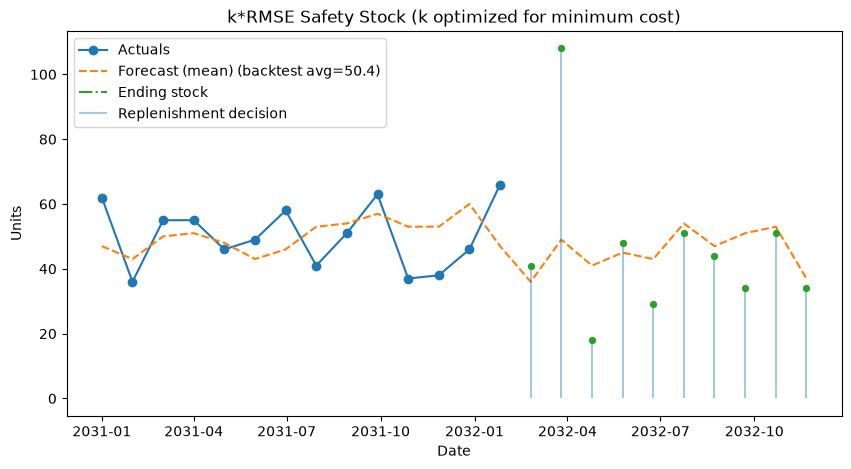

In [5]:
eval_policy_cost = _candidate_policy(
    best_k_cost, [r.forecast for r in forecast_rows], backtest_actuals,
)
current_stock = forecast_rows[0].current_stock
simulation_cost = simulate_replenishment(
    periods=len(forecast_rows), demand=[r.demand for r in forecast_rows], initial_on_hand=current_stock,
    lead_time=lead_time, policy=eval_policy_cost,
    holding_cost_per_unit=forecast_rows[0].holding_cost_per_unit,
    stockout_cost_per_unit=forecast_rows[0].stockout_cost_per_unit,
    order_cost_per_order=forecast_rows[0].order_cost_per_order,
)
decision_rows_cost = [
    ReplenishmentDecisionRow(
        unique_id=row.unique_id, ds=row.ds, quantity=snapshot.order_placed,
        demand=snapshot.demand, incoming_stock=snapshot.received,
        starting_on_hand=snapshot.starting_on_hand, ending_on_hand=snapshot.ending_on_hand,
        on_order=snapshot.on_order, backorders=snapshot.backorders, sigma=best_k_cost,
    )
    for row, snapshot in zip(forecast_rows, simulation_cost.snapshots)
]
decision_df_cost = replenishment_decision_rows_to_dataframe(decision_rows_cost, library="pandas")
example_id = decision_df_cost["unique_id"].iloc[0]
plot_replenishment_decisions(
    rows_df, decision_df_cost, unique_id=example_id,
    title="k*RMSE Safety Stock (k optimized for minimum cost)", decision_style="line",
)

## 2) Optimize `k` with Fill-Rate Target
Unlike a cost minimization, we simulate every candidate `k` on the backtest window directly and keep the one whose realized fill rate is closest to the target.

In [6]:
fill_rows = []
best_k_fill = None
best_diff = None
for k in candidate_k:
    policy = _candidate_policy(k, [r.forecast for r in backtest_rows], backtest_actuals)
    simulation = simulate_replenishment(
        periods=len(backtest_rows), demand=[r.actuals for r in backtest_rows],
        initial_on_hand=backtest_rows[0].initial_on_hand, lead_time=lead_time, policy=policy,
        holding_cost_per_unit=backtest_rows[0].holding_cost_per_unit,
        stockout_cost_per_unit=backtest_rows[0].stockout_cost_per_unit,
        order_cost_per_order=backtest_rows[0].order_cost_per_order,
    )
    diff = abs(simulation.summary.fill_rate - target_fill_rate)
    fill_rows.append({
        "k": k, "backtest_fill_rate": simulation.summary.fill_rate,
        "meets_target": simulation.summary.fill_rate >= target_fill_rate, "abs_diff": diff,
    })
    if best_diff is None or diff < best_diff:
        best_diff = diff
        best_k_fill = k

fill_summary = pd.DataFrame(fill_rows).sort_values("k")
best_k_fill, fill_summary

(4.0,
      k  backtest_fill_rate  meets_target  abs_diff
 0  0.0            0.480797         False  0.469203
 1  0.5            0.520626         False  0.429374
 2  1.0            0.561878         False  0.388122
 3  1.5            0.603129         False  0.346871
 4  2.0            0.645804         False  0.304196
 5  2.5            0.689900         False  0.260100
 6  3.0            0.722617         False  0.227383
 7  3.5            0.753912         False  0.196088
 8  4.0            0.780939         False  0.169061)

<Axes: title={'center': 'k*RMSE Safety Stock (target fill rate = 95%)'}, xlabel='Date', ylabel='Units'>

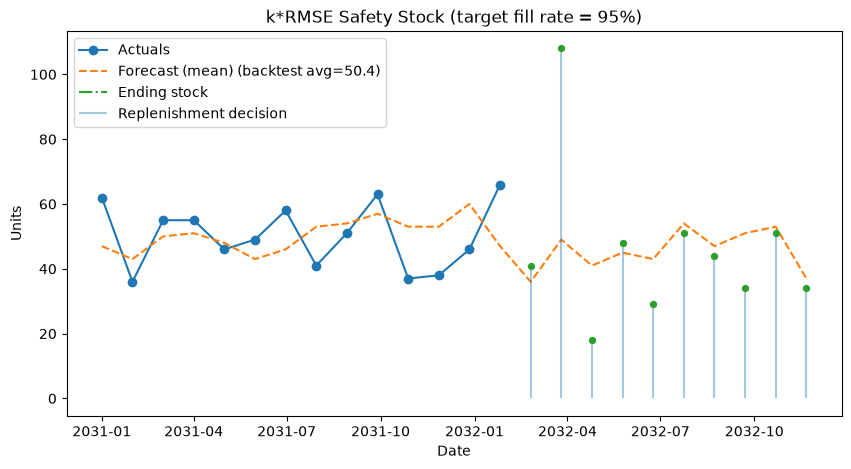

In [7]:
eval_policy_fill = _candidate_policy(
    best_k_fill, [r.forecast for r in forecast_rows], backtest_actuals,
)
simulation_fill = simulate_replenishment(
    periods=len(forecast_rows), demand=[r.demand for r in forecast_rows], initial_on_hand=current_stock,
    lead_time=lead_time, policy=eval_policy_fill,
    holding_cost_per_unit=forecast_rows[0].holding_cost_per_unit,
    stockout_cost_per_unit=forecast_rows[0].stockout_cost_per_unit,
    order_cost_per_order=forecast_rows[0].order_cost_per_order,
)
decision_rows_fill = [
    ReplenishmentDecisionRow(
        unique_id=row.unique_id, ds=row.ds, quantity=snapshot.order_placed,
        demand=snapshot.demand, incoming_stock=snapshot.received,
        starting_on_hand=snapshot.starting_on_hand, ending_on_hand=snapshot.ending_on_hand,
        on_order=snapshot.on_order, backorders=snapshot.backorders, sigma=best_k_fill,
    )
    for row, snapshot in zip(forecast_rows, simulation_fill.snapshots)
]
decision_df_fill = replenishment_decision_rows_to_dataframe(decision_rows_fill, library="pandas")
plot_replenishment_decisions(
    rows_df, decision_df_fill, unique_id=example_id,
    title=f"k*RMSE Safety Stock (target fill rate = {target_fill_rate:.0%})", decision_style="line",
)

## Notes

- Other safety-stock strategies are available: `SqrtHorizonSafetyStock` (the default,
  horizon-scaled), `KMaeSafetyStock` (flat, MAE-based).
- This notebook intentionally uses `KRmseSafetyStock` to apply raw `k * RMSE`.